In [101]:
import numpy as np
from numpy import pi,cos,sin,exp
import matplotlib.pyplot as plt

#for coloring lines
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import blochK
import blochK.observable as observable
from blochK.plotting import plot_FS, plot_bandstruc
from blochK.plotting.utils import extent
from blochK.plotting.publication import paper_style,paper_style_small, revtex_textwidth, revtex_columnwidth, set_size

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from alter_surf.hamiltonian_DLKK import create_H_DLKK_3D, create_H_DLKK_3D_MF
from alter_surf.utils3D import projector2layer, cmap_bkr, two_param_color
from alter_surf.utils_DLKK import get_conductivity_layer_resolved

import pickle
from tqdm import tqdm

%load_ext autoreload
%autoreload 2



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Figure DLKK MF results

In [71]:
with open('MF_solution_DLKK_n=0.54_U=4_L=50.pkl','rb') as f:
    Hparam = pickle.load(f)
f.close()
print('Mean-field parameters loaded.')

#create Hamiltonian with MF parameters
H_MF = create_H_DLKK_3D_MF(param=Hparam)

#create Hamiltonian with values for MF parameters
Hparam_0 = Hparam.copy()
Hparam_0['mAF'] = np.mean(np.abs(Hparam['mAF'])) * np.sign(Hparam['mAF'])
Hparam_0['ns'] = np.mean(Hparam['ns'])*np.ones_like(Hparam['ns'])
H_0 = create_H_DLKK_3D_MF(param=Hparam_0)


#compute spin conductance
layers_c, cond_MF, spin_cond_MF = get_conductivity_layer_resolved(H_MF,Lk=10)
layers_c, cond_0, spin_cond_0 = get_conductivity_layer_resolved(H_0,Lk=10)
print('Conductivity computed.')

# loading the spectral density data
with open('spectral_densitys_DLKK_MF_n=0.54_U=6_L=101.pkl', 'rb') as f:
    data = pickle.load(f)    
f.close()
spectral_density = data['spectral_density'] 
spin_spectral_density = data['spin_spectral_density']
ks = data['k_mesh']
layers = data['layers']



Mean-field parameters loaded.
Conductivity computed.


<>:31: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
/var/folders/xb/6hhfs1vn32s_g5b9xk9fx8yh0000gn/T/ipykernel_31839/2051737449.py:31: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('spin spliter angle [$^\circ$]')


0.870718523716828 0.008348506566920506


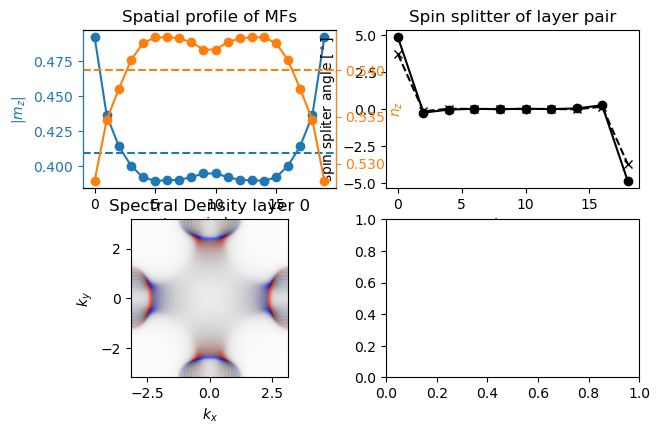

In [ ]:



fig,axs = plt.subplots(2,2, figsize=set_size(revtex_textwidth))

fig = plt.figure(figsize=set_size(revtex_textwidth))


ax = axs[0,0]
ax.set_title('Spatial profile of MFs')

ax.plot(np.arange(Hparam['len_z']), np.abs(H_MF.param['mAF']),'-o',color='C0')
axR = ax.twinx()
axR.plot(np.arange(Hparam['len_z']), H_MF.param['ns']/2,'-o', color='C1')

ax.axhline(np.mean(np.abs(H_MF.param['mAF'])), ls='--', color='C0')
axR.axhline(np.mean(H_MF.param['ns']/2), ls='--', color='C1')

axR.spines['left'].set_color('C0')
ax.yaxis.label.set_color('C0')
ax.tick_params(axis='y', colors='C0')
axR.spines['right'].set_color('C1')
axR.yaxis.label.set_color('C1')
axR.tick_params(axis='y', colors='C1')

ax.set_xlabel('Layer index z')
ax.set_ylabel(r'$|m_z|$')
axR.set_ylabel(r'$n_z$')


ax = axs[0,1]
ax.set_title('Spin splitter of layer pair')
ax.plot(layers_c,2*np.arctan(spin_cond_MF[:,0,0]/cond_MF[:,0,0])*180/pi,'o-',color='k')
ax.plot(layers_c,2*np.arctan(spin_cond_0[:,0,0]/cond_0[:,0,0])*180/pi,'x--',color='k')
ax.set_xlabel('Layer')
#ax.set_yscale('symlog',linthresh=1)
ax.set_ylabel('spin spliter angle [$^\circ$]')


#########################################
#spectral density plotting
#########################################
colors = spin_spectral_density.copy()
alphas = spectral_density.copy()

#nomalize for plotting
colors = spin_spectral_density/np.max(np.abs(spin_spectral_density))
alphas = spectral_density/np.max(np.abs(spectral_density))

#power law for better visibility
colors = np.sign(colors)*np.abs(colors)**0.7
alphas = alphas**0.8

imshow_kwargs = dict(origin='lower',vmax=1, vmin=-1,interpolation='spline36')


ax = axs[1,0]
numb_ks = ks.shape[1]
ax.set_title('Spectral Density layer 0')
ax.set_xlabel('$k_x$')
ax.set_ylabel('$k_y$')
numb_ks = ks.shape[1]

i=0
colors0 = colors[i].T
alphas0 = alphas[i].T
ax.imshow(two_param_color(colors0, alphas0), **imshow_kwargs, extent=extent(numb_ks))

print(alphas0.max(), alphas0.min())



# Figure DLKK model V0

In [ ]:
Hparam = dict(len_z=14,delta=1, tp=0.3, tz=1, PBC=False, mAF=3,mu=3.1) #strong d-wave pattern. pockets roughly spherical
H_DLKK = create_H_DLKK_3D(param=Hparam) #set up Hamiltonian with fixed len_z because it defines n_orbitals

with open('spectral_densitys_DLKK.pkl', 'rb') as f:
    data = pickle.load(f)    
f.close()
spectral_density = data['spectral_density'] 
spin_spectral_density = data['spin_spectral_density']
ks = data['k_mesh']
layers = data['layers']




In [57]:
#load MF solution
with open('MF_solution_DLKK_n=0.51_U=6_L=50.pkl','rb') as f:
    Hparam = pickle.load(f)
f.close()

#load conductivity data
with open('conductivity_DLKK_n=0.51_U=6_L=50.pkl','rb') as f:
    data = pickle.load(f)
layers = data['layers']
spin_cond_xx = data['spin_cond_xx']
cond_xx = data['cond_xx']
f.close()

#create Hamiltonian with MF parameters
H_DLKK = create_H_DLKK_3D_MF(param=Hparam)

#find the eigenvalues and the eigenvectors
ks = H_DLKK.BZ.sample(100)
es,psis = H_DLKK.diagonalize(*ks)

###############################
#compute spectral density of layer pairs
#at surface and bulk
Gamma = 5e-2 #spectral boadening
###############################
#1) at surface
layer = 0
proj_2layers = projector2layer(layer,len_z=Hparam['len_z'])+projector2layer(layer+1,len_z=Hparam['len_z'])
coloring_operator = np.kron(proj_2layers,H_DLKK.suboperator.spin) #projected spin_operator
#compute spin spectral density
Os = observable.exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
spectral_density_spin_surf = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/Hparam['len_z']
#compute spectral density
Os = observable.exp_value_O(np.kron(proj_2layers,np.ones(4)),psis) #.shape=(n,y,x)
spectral_density_surf = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/Hparam['len_z']
###############################
#2) at bulk
layer = Hparam['len_z']//2
proj_2layers = projector2layer(layer,len_z=Hparam['len_z'])+projector2layer(layer+1,len_z=Hparam['len_z'])
coloring_operator = np.kron(proj_2layers,H_DLKK.suboperator.spin) #projected spin_operator
#compute spin spectral density
Os = observable.exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
spectral_density_spin_bulk = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/Hparam['len_z']
#compute spectral density
Os = observable.exp_value_O(np.kron(proj_2layers,np.ones(4)),psis) #.shape=(n,y,x)
spectral_density_bulk = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/Hparam['len_z'] 
###############################


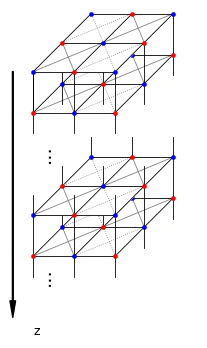

In [166]:
# lets create a schematic of the lattice structure

fig, ax = plt.subplots(figsize=(4,4))

def draw_layer(ax,x0=0,y0=0,ordering=0,colors_spin=['red','blue'],zorder=0):

    dy = 2**0.5/2 #length of the 3D looking axis going back
    ax.add_patch(plt.Polygon([(x0, y0), (x0 + 2,y0), (x0+2+2*dy,y0+2*dy), (x0 + 2*dy,y0+2*dy)], color='white', zorder=1+zorder))

    #NN hopping lines
    ax.plot([x0,x0+2],[y0,y0],color='k',zorder=3+zorder)
    ax.plot([x0+1,x0+1+2*dy],[y0,y0+2*dy],color='k',zorder=3+zorder)
    ax.plot([x0+2,x0+2+2*dy],[y0,y0+2*dy],color='k',zorder=3+zorder)
    ax.plot([x0+2+2*dy,x0+2*dy],[y0+2*dy,y0+2*dy],color='k',zorder=3+zorder)
    ax.plot([x0+2*dy,x0],[y0+2*dy,y0],color='k',zorder=3+zorder)
    ax.plot([x0+dy,x0+2+dy],[y0+dy,y0+dy],color='k',zorder=3+zorder)

    #NNN hopping lines
    ax.plot([x0,x0+2+2*dy],[y0,y0+2*dy],color='gray',linestyle='-',zorder=2+zorder)
    ax.plot([x0+dy,x0+1],[y0+dy,y0],color='gray',linestyle='-',zorder=2+zorder)
    ax.plot([x0+1+dy,x0+2],[y0+dy,y0],color='gray',linestyle=':',zorder=2+zorder)
    ax.plot([x0+1+dy,x0+2*dy],[y0+dy,y0+2*dy],color='gray',linestyle=':',zorder=2+zorder)
    ax.plot([x0+1,x0+2+dy],[y0,y0+1*dy],color='gray',linestyle=':',zorder=2+zorder)
    ax.plot([x0+1+2*dy,x0+dy],[y0+2*dy,y0+dy],color='gray',linestyle=':',zorder=2+zorder)
    ax.plot([x0+1+2*dy,x0+2+dy],[y0+2*dy,y0+dy],color='gray',linestyle='-',zorder=2+zorder)

    #atoms
    if ordering==0:
        colors = [colors_spin[0],colors_spin[1]]
    else :
        colors = [colors_spin[1],colors_spin[0]]
    ax.plot([x0,x0+2,x0+1+dy,x0+2*dy,x0+2+2*dy],[y0,y0,y0+dy,y0+2*dy,y0+2*dy],'o',color=colors[0],zorder=8+zorder)
    ax.plot([x0+1,x0+dy,x0+1+2*dy,x0+2+dy],[y0,y0+dy,y0+2*dy,y0+dy],'o',color=colors[1],zorder=8+zorder)




def draw_lattice(ax):
    dz = 1
    dy = 2**0.5/2

    ax.set_xlim(-0.5,4)
    ax.set_aspect('equal')
    ax.set_ylim(-5,dz + 2*dy+0.1)


    #the bulk layers
    y_shift=-3.5
    draw_layer(ax,x0=0.,y0=y_shift)
    draw_layer(ax,x0=0.,y0=y_shift+dz,ordering=1,zorder=10)
    for x0,y0 in [(0,y_shift),(1,y_shift),(2,y_shift),(2+dy,y_shift+dy),(2+2*dy,y_shift+2*dy),(dy,y_shift+dy),(1+dy,y_shift+dy),(2*dy,y_shift+2*dy),(1+2*dy,y_shift+2*dy)]:
        ax.plot([x0,x0],[y0,y0+dz],color='k',zorder=3) #hoppings bettween layers
        ax.plot([x0,x0],[y0+dz,y0+3*dz/2],color='k',zorder=13) #hoppings up top layer
        ax.plot([x0,x0],[y0,y0-dz/2],color='k',zorder=0) #hoppings down lower layer
    ax.plot([0,0],[0,dz],color='k',zorder=3)

    #the surface layers
    draw_layer(ax,zorder=20)
    draw_layer(ax,x0=0.,y0=dz,ordering=1,zorder=30)
    for x0,y0 in [(0,0),(1,0),(2,0),(2+dy,dy),(2+2*dy,2*dy),(dy,dy),(1+dy,dy)]:
        ax.plot([x0,x0],[y0-dz/2,y0+dz],color='k',zorder=23)
    ax.plot([0,0],[0,dz],color='k',zorder=3)


    # Remove frame and ticks
    ax.axis('off')

    # Add z-axis arrow
    ax.annotate('', xy=(-0.5, -5), xytext=(-0.5, 1),
                arrowprops=dict(facecolor='black', shrink=0, width=0.5, headwidth=4))
    ax.text(0, -5.5, 'z', fontsize=9, va='bottom', ha='left')

    # Add three dots to indicate infinite extension downward
    ax.text(0.5, -1, '...', fontsize=14, va='center', ha='right',rotation=90,zorder=100)
    ax.text(0.5, -4, '...', fontsize=14, va='center', ha='right',rotation=90,zorder=100)

    return dy,dz,y_shift

dy,dz,y_shift = draw_lattice(ax)

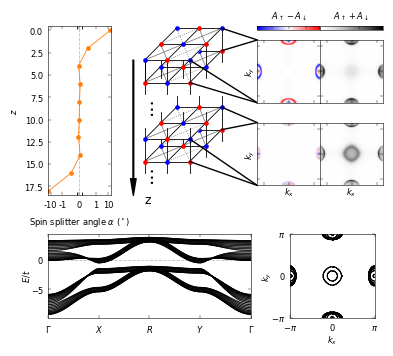

In [175]:
draft = False #quick vs slow plotting
if draft:
    N_samples = 30
    Lk = 5
else:
    N_samples = 100
    Lk = 100

fig = plt.figure(figsize=set_size(revtex_columnwidth,ratio=0.8))
gs = fig.add_gridspec(2,1, hspace=0.3, height_ratios=[2,1]) #split into two rows

gs1 = gs[0].subgridspec(1,3, wspace=0.1, width_ratios=[1,2,2])
gs4 = gs1[2].subgridspec(3,2, wspace=0., hspace=0.,height_ratios=[0.05,1,1])
gs2 = gs[1].subgridspec(1,2, wspace=0.2, width_ratios=[2,1])

axs = []
axs.append(fig.add_subplot(gs1[0]))
axs.append(fig.add_subplot(gs1[1]))
axs_bottom = [fig.add_subplot(gs2[0]),
              fig.add_subplot(gs2[1])]

axs4 = np.array([[fig.add_subplot(gs4[0,0]) , fig.add_subplot(gs4[0,1])],
                 [fig.add_subplot(gs4[1,0]) , fig.add_subplot(gs4[1,1])],
                 [fig.add_subplot(gs4[2,0]) , fig.add_subplot(gs4[2,1])]])

fig.subplots_adjust(left=0.03, right=0.96, bottom=0, top=1)
plt.rcParams.update(paper_style_small)


#####################################
# Model system schematic
#####################################
ax = axs[1]
dy,dz,y_shift = draw_lattice(ax)

#####################################
# Spin splitter angle
#####################################
ax = axs[0]

spin_splitter_angle = 2*np.arctan(spin_cond_xx/cond_xx)*180/pi
ax.axvline(0,color='gray',ls='--',alpha=0.5) #show zero line
ax.plot(spin_splitter_angle,layers,'o-',color='C1')
ax.set_ylim(layers[-1]+0.5,-0.5)
ax.set_xscale('symlog', linthresh=0.5)
ax.set_xlabel(r'Spin splitter angle $\alpha$ ($^\circ$)')
ax.set_ylabel('$z$')
ax.set_xticks([-10,-1,0,1,10])
ax.set_xticklabels([-10,-1,0,1,10])

#####################################
# Spectral functions
#####################################
spin_max = np.max(np.abs(spectral_density_spin_surf))
dens_max = np.max([spectral_density_surf,spectral_density_bulk])

for i in range(2):
    for j in range(2):
        ax = axs4[1+i,j]
        ax.sharex(axs4[1,0])
        ax.sharey(axs4[1,0])
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        if i==1:
            ax.set_xlabel(r'$k_x$',labelpad=-3)
        if j==0:
            ax.set_ylabel(r'$k_y$',labelpad=-3)
    
#plot spectral densities
ims = np.zeros((2,2),dtype=object)
ims[0,0] = axs4[1,0].imshow(spectral_density_spin_surf,extent=extent(ks),origin='lower',cmap='bwr',vmin=-spin_max,vmax=spin_max)
ims[1,0] = axs4[2,0].imshow(spectral_density_spin_bulk,extent=extent(ks),origin='lower',cmap='bwr',vmin=-spin_max,vmax=spin_max)
ims[0,1] = axs4[1,1].imshow(spectral_density_surf,extent=extent(ks),origin='lower',cmap='Greys',vmin=0,vmax=dens_max)
ims[1,1] = axs4[2,1].imshow(spectral_density_bulk,extent=extent(ks),origin='lower',cmap='Greys',vmin=0,vmax=dens_max)

#colorbars
#create spin colobar
fig.colorbar(ims[0,0], cax=axs4[0,0], orientation='horizontal')
axs4[0,0].xaxis.set_ticks_position("top")
axs4[0,0].xaxis.set_label_position("top")
axs4[0,0].set_xticklabels([])
axs4[0,0].set_xlabel(r'$A_\uparrow-A_\downarrow$',labelpad=2)
#creat density colorbar
fig.colorbar(ims[0,1], cax=axs4[0,1], orientation='horizontal')
axs4[0,1].xaxis.set_ticks_position("top")
axs4[0,1].xaxis.set_label_position("top")
axs4[0,1].set_xticklabels([])
axs4[0,1].set_xlabel(r'$A_\uparrow+A_\downarrow$',labelpad=2)

#####################################
# Bandstructure
#####################################
ax = axs_bottom[0]
coloring_operator = H_DLKK.operator.spin
labels = ['\Gamma',"X","R","Y",'\Gamma']
ax.axhline(0,color='gray',ls='--',alpha=0.5) #show zero line
plot_bandstruc(ax,H_DLKK,labels_points_path=labels,coloring_operator=coloring_operator,cmap='bwr',N_samples=N_samples)

#####################################
# Fermi surface
#####################################
ax = axs_bottom[1]
plot_FS(ax,H_DLKK,coloring_operator=coloring_operator,cmap='bwr',Lk=Lk)


#add connection between surface schematic and spectral function
from matplotlib.patches import ConnectionPatch
for xyA,xyB in zip([(2,0),(2,dz),(2+2*dy,2*dy),(2+2*dy,2*dy+dz)],[(0,0),(0,0),(0,1),(0,1)]):
    con = ConnectionPatch(
        xyA=xyA, coordsA=axs[1].transData,      # first point in data coords
        xyB=xyB, coordsB=axs4[1,0].transAxes,      # second point in axes coords
        arrowstyle='-', color='black',zorder=0
    )
    ax.add_artist(con)

for xyA,xyB in zip([(2,y_shift),(2,y_shift+dz),(2+2*dy,y_shift+2*dy),(2+2*dy,y_shift+2*dy+dz)],[(0,0),(0,0),(0,1),(0,1)]):
    con = ConnectionPatch(
        xyA=xyA, coordsA=axs[1].transData,      # first point in data coords
        xyB=xyB, coordsB=axs4[2,0].transAxes,      # second point in axes coords
        arrowstyle='-', color='black',zorder=0
    )
    ax.add_artist(con)


if not draft:
    fig.savefig('Fig_DLKK.pdf',bbox_inches='tight')